# Module 2 – Yearly Mean Analysis
# Same structure as the monthly version (plot_test_v5) but using annual means.
# Key difference: yearly aggregation averages out the 12-month seasonal cycle,
# so seasonal standardisation is NOT needed before fitting AR/ARMA.
# Pipeline:
#   1. Resample to annual means (YE)
#   2. Test and remove linear trend
#   3. Gap-aware ACF/PACF (max_lag = 10 years)
#   4. Fit AR and ARMA on detrended series
#   5. Evaluate: theoretical ACF, residual ACF, PPCC, Ljung-Box


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, probplot, pearsonr
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox


In [2]:
#Change root to your folder path
#root = r'c:\Users\leoni\OneDrive\Documents\Master Umwelting ETH\Semester 2\Labor WRM\Asssignment 2\Assignment 2-20260512\DATA\DATA'
root = r'C:\Users\Sylvie\OneDrive\ETH\Master\2_Semester\Lab_WRM\2_ex\DATA\DATA'
qD = pd.read_csv(os.path.join(root,'Q_Diepoldsau_m3s.csv'), parse_dates=['timestamp']).set_index('timestamp')
qG = pd.read_csv(os.path.join(root,'Q_Gisingen_1976-2023.csv'), parse_dates=['timestamp']).set_index('timestamp')
sscD = pd.read_csv(os.path.join(root,'SSC_Diepoldsau_gL.csv'), parse_dates=['timestamp']).set_index('timestamp')
sscG = pd.read_csv(os.path.join(root,'SSC_Gisingen_2003-2020.csv'), parse_dates=['timestamp']).set_index('timestamp')

In [3]:
display(qD.head(2))
display(qG.head(2))
display(sscD.head(2))
display(sscG.head(2))

,q_m3s
timestamp,
1984-01-01 00:00:00,113.081
1984-01-01 00:10:00,113.044


,q_m3s
timestamp,
1976-01-01 00:15:00,18.8
1976-01-01 00:30:00,18.7


,ssc_gL
timestamp,
2012-01-01 00:00:00,0.01785
2012-01-01 00:10:00,NaN


,ssc_gL
timestamp,
2004-01-01 00:00:00,0.0153
2004-01-01 00:15:00,0.0143


In [4]:
# Resample to annual means
# Yearly aggregation averages out the within-year seasonal cycle completely,
# so no seasonal standardisation is needed before ARMA fitting.
qD   = qD.resample('YE').mean()
qG   = qG.resample('YE').mean()
sscD = sscD.resample('YE').mean()
sscG = sscG.resample('YE').mean()

print('Sample sizes after annual aggregation:')
print(f'  Q   Diepoldsau : {len(qD.dropna())} years')
print(f'  Q   Gisingen   : {len(qG.dropna())} years')
print(f'  SSC Diepoldsau : {len(sscD.dropna())} years')
print(f'  SSC Gisingen   : {len(sscG.dropna())} years')


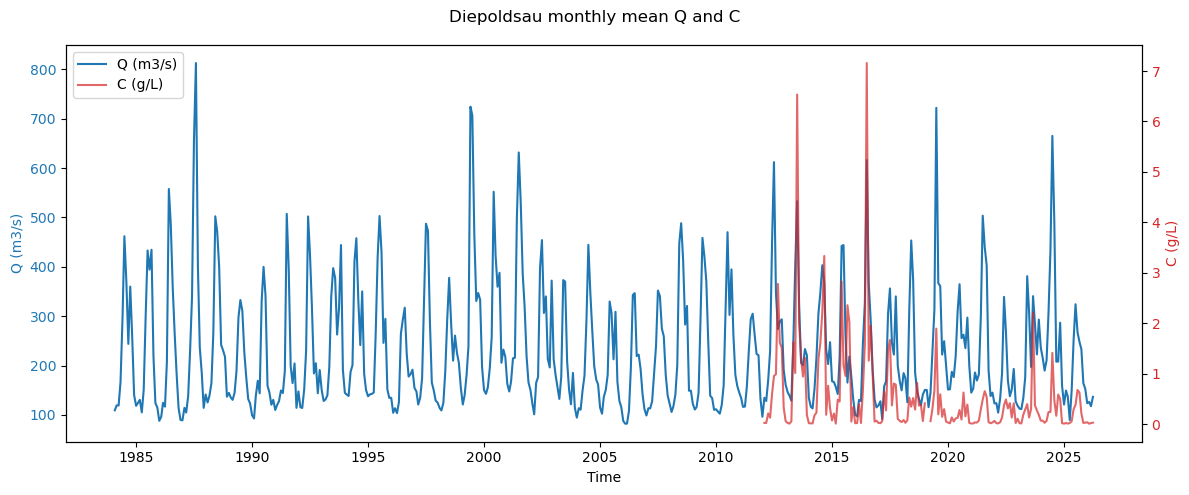

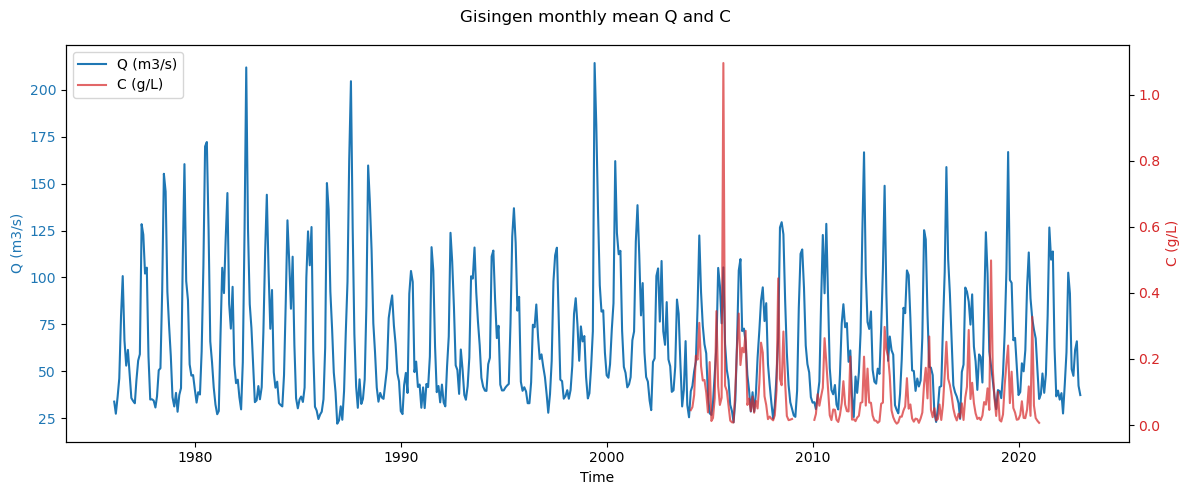

In [5]:
for station, dfQ, dfC in [('Diepoldsau', qD, sscD), ('Gisingen', qG, sscG)]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(dfQ.index, dfQ['q_m3s'], marker='o', label='Q (m³/s)', color='tab:blue')
    ax.set_xlabel('Year')
    ax.set_ylabel('Q (m³/s)', color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')
    ax2 = ax.twinx()
    ax2.plot(dfC.index, dfC.iloc[:, 0], marker='s', label='C (g/L)',
             color='tab:red', alpha=0.7)
    ax2.set_ylabel('C (g/L)', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    lines, labels   = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc='upper left')
    fig.suptitle(f'{station} – annual mean Q and C')
    fig.tight_layout()
    plt.show()


# 1.2 Stationarity test and trend removal
Linear trend test at 5% significance on each annual series.
With yearly data, the seasonal cycle is already removed by aggregation.
We still remove any significant long-term linear trend before ARMA fitting.


Diepoldsau Q: n=507, slope=-0.019002, p=0.6136, significant=False
    detrend method = mean
    mean after detrending = -2.421731e-14
    variance after detrending = 1.533543e+04

Diepoldsau C: n=169, slope=-0.006028, p=0.0000, significant=True
    detrend method = linear trend
    mean after detrending = -8.146015e-17
    variance after detrending = 7.961486e-01

Gisingen Q: n=564, slope=-0.007518, p=0.3952, significant=False
    detrend method = mean
    mean after detrending = 7.710145e-15
    variance after detrending = 1.166312e+03

Gisingen C: n=192, slope=-0.000396, p=0.0076, significant=True
    detrend method = linear trend
    mean after detrending = 2.370789e-17
    variance after detrending = 1.265569e-02



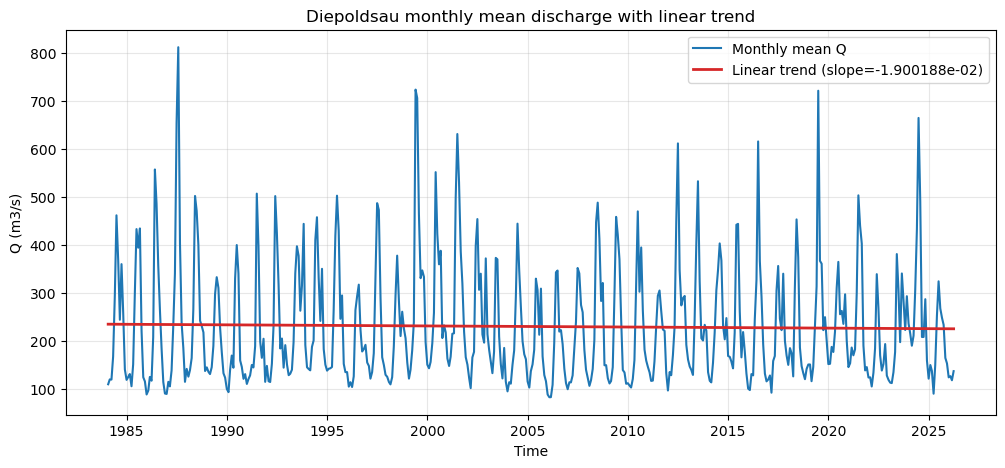

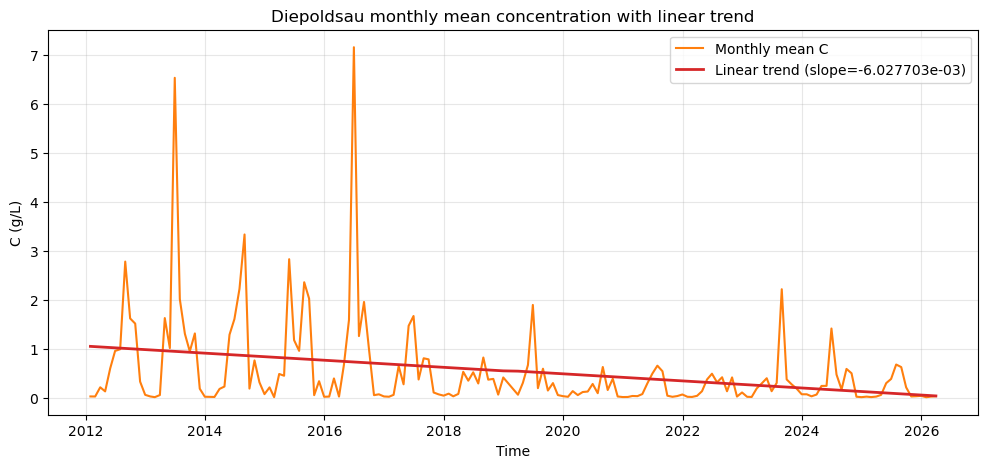

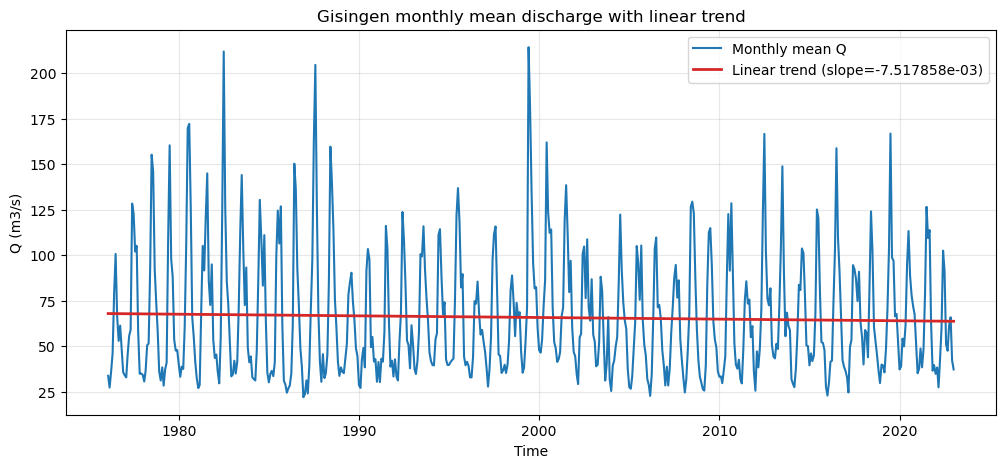

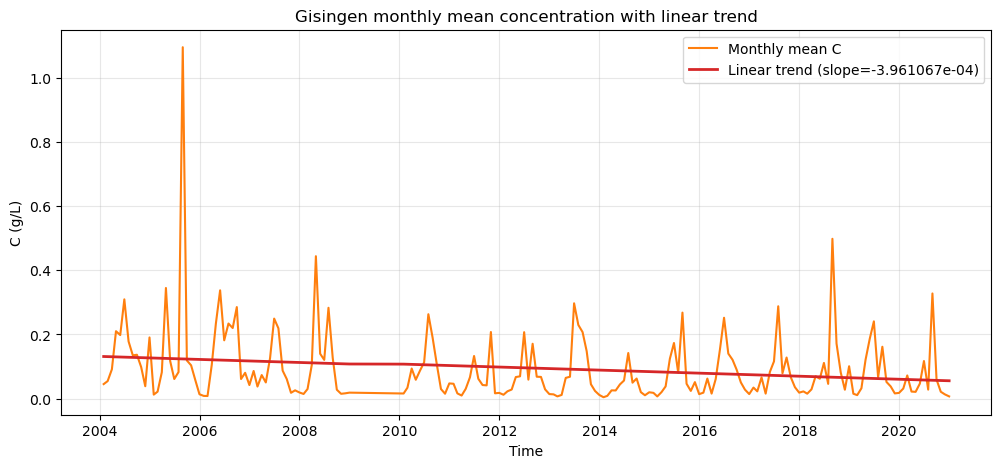

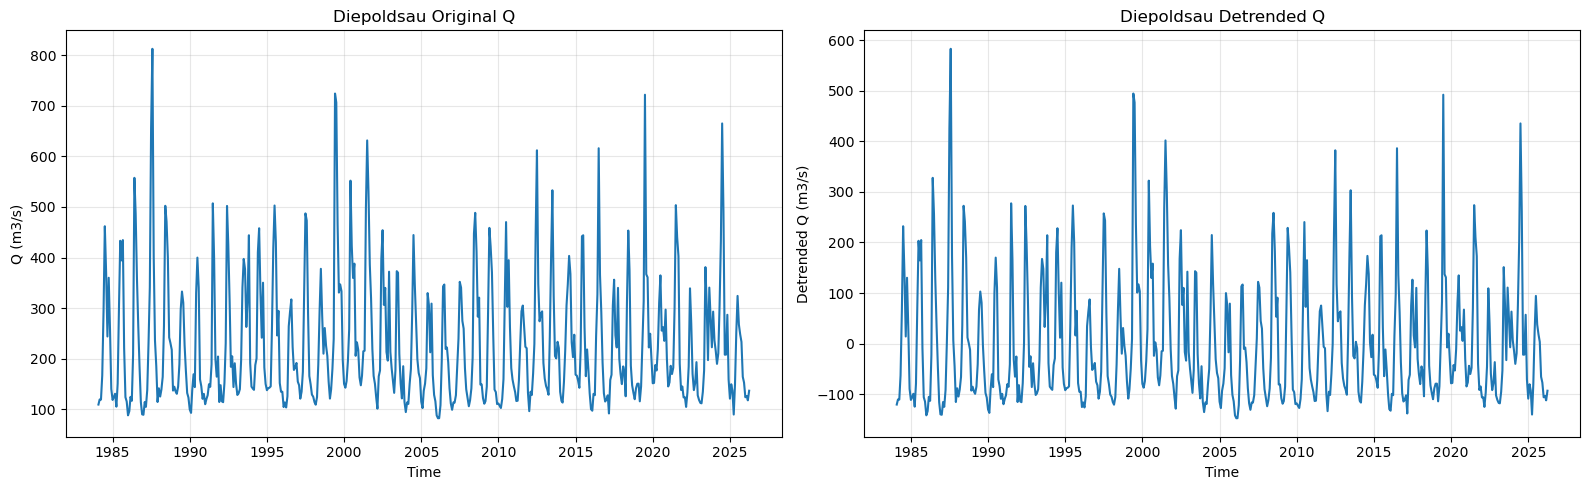

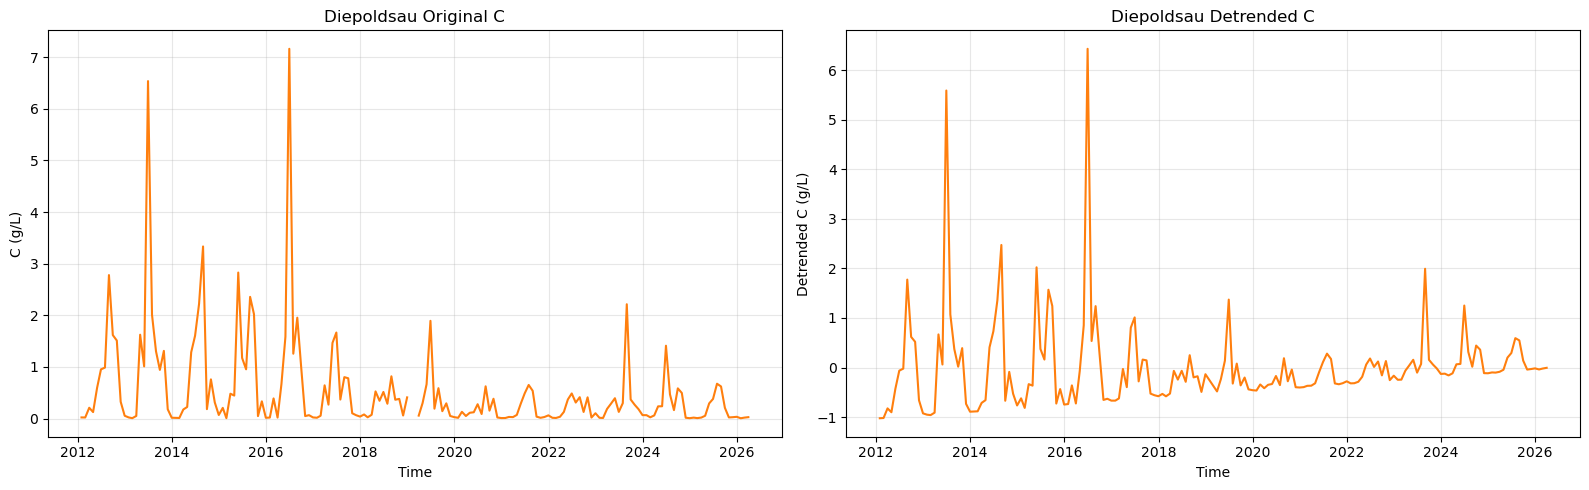

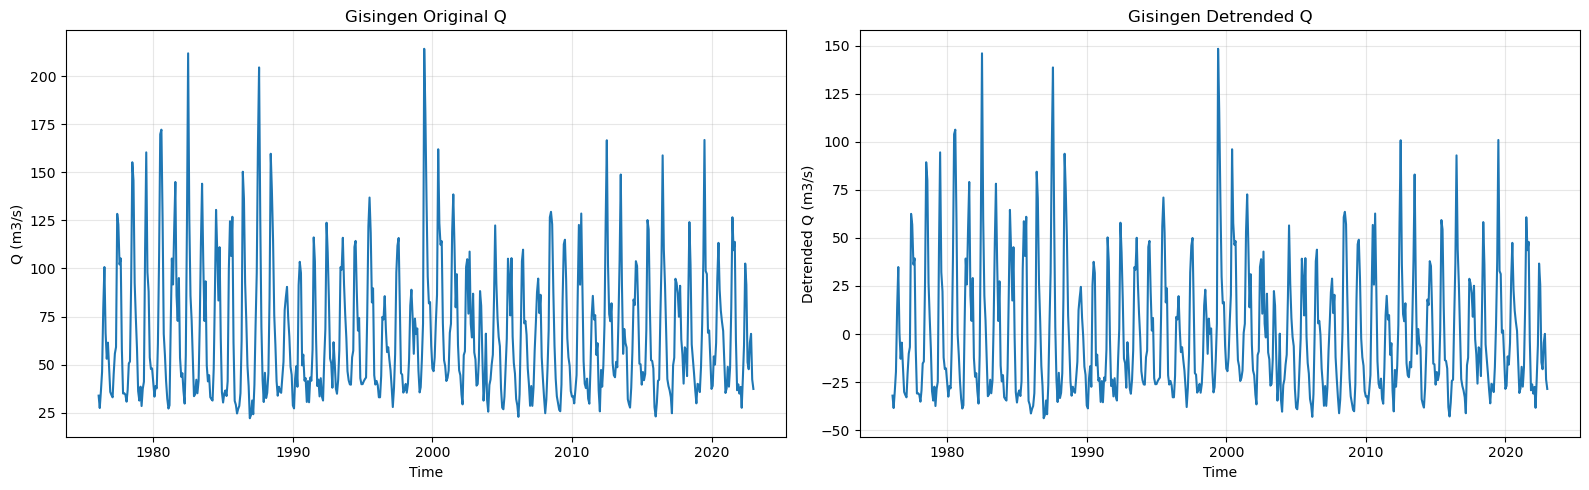

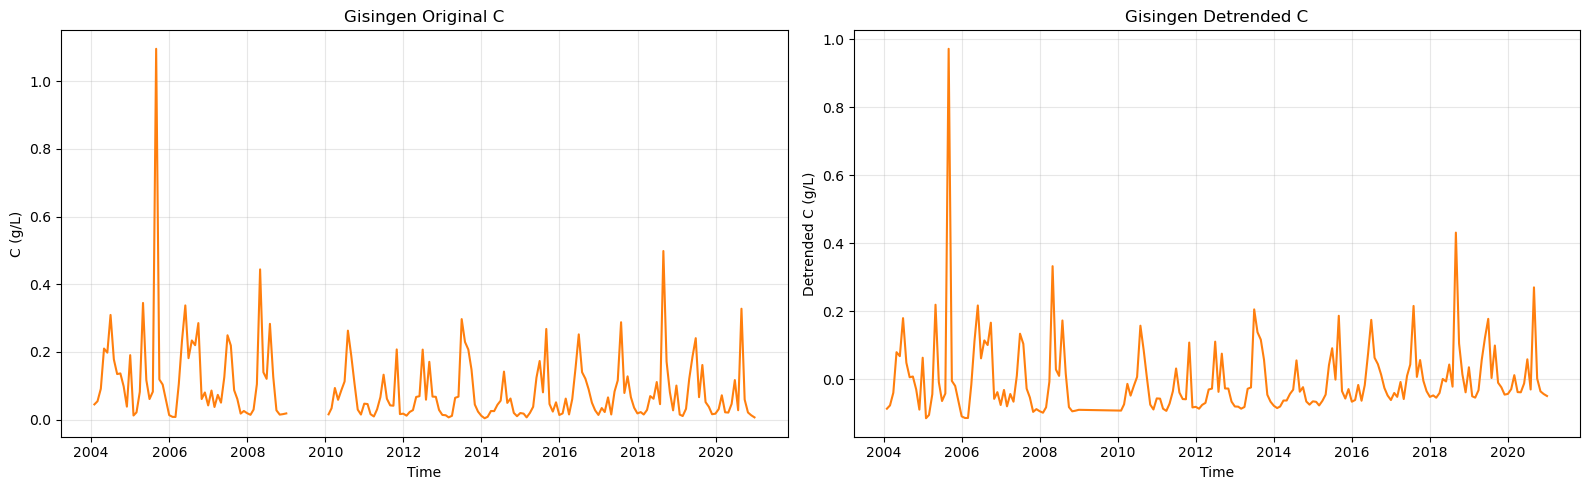

In [6]:
def test_and_detrend(df, column_name):

    y = df[column_name].dropna()
    x = np.arange(len(y))
    trend = linregress(x, y.values)
    pvalue = trend.pvalue
    significant = pvalue < 0.05
    if significant:
        detrended = y.values - (trend.intercept + trend.slope * x)
        detrend_method = 'linear trend'
    else:
        detrended = y.values - y.values.mean()
        detrend_method = 'mean'
    detrended_mean = detrended.mean()
    detrended_var = detrended.var(ddof=1)
    detrended_series = pd.Series(detrended, index=y.index)
    
    results = {
        'n_points': len(y),
        'slope': trend.slope,
        'pvalue': pvalue,
        'significant': significant,
        'detrend_method': detrend_method,
        'mean_after_detrend': detrended_mean,
        'variance_after_detrend': detrended_var,
    }
    return detrended_series, results

station_results = []
detrended_series = {}

for station, dfQ, dfC in [('Diepoldsau', qD, sscD), ('Gisingen', qG, sscG)]:
    # Detrend Q
    detrended_Q, results_Q = test_and_detrend(dfQ, 'q_m3s')
    detrended_series[f'Q_{station}'] = detrended_Q
    station_results.append({
        'station': station,
        'variable': 'Q',
        **results_Q
    })
    print(f"{station} Q: n={results_Q['n_points']}, slope={results_Q['slope']:.6f}, p={results_Q['pvalue']:.4f}, significant={results_Q['significant']}")
    print(f"    detrend method = {results_Q['detrend_method']}")
    print(f"    mean after detrending = {results_Q['mean_after_detrend']:.6e}")
    print(f"    variance after detrending = {results_Q['variance_after_detrend']:.6e}\n")
    
    # Detrend C (SSC)
    detrended_C, results_C = test_and_detrend(dfC, dfC.columns[0])
    detrended_series[f'C_{station}'] = detrended_C
    station_results.append({
        'station': station,
        'variable': 'C',
        **results_C
    })
    print(f"{station} C: n={results_C['n_points']}, slope={results_C['slope']:.6f}, p={results_C['pvalue']:.4f}, significant={results_C['significant']}")
    print(f"    detrend method = {results_C['detrend_method']}")
    print(f"    mean after detrending = {results_C['mean_after_detrend']:.6e}")
    print(f"    variance after detrending = {results_C['variance_after_detrend']:.6e}\n")

station_results_df = pd.DataFrame(station_results)
station_results_df

# Plot linear regression fit for each station and variable
for station, dfQ, dfC in [('Diepoldsau', qD, sscD), ('Gisingen', qG, sscG)]:
    # Plot for Q
    yQ = dfQ['q_m3s'].dropna()
    xQ = np.arange(len(yQ))
    trendQ = linregress(xQ, yQ.values)
    fittedQ = trendQ.intercept + trendQ.slope * xQ

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(yQ.index, yQ, label='Monthly mean Q', color='tab:blue')
    ax.plot(yQ.index, fittedQ, label=f'Linear trend (slope={trendQ.slope:.6e})', color='tab:red', linewidth=2)
    ax.set_title(f'{station} monthly mean discharge with linear trend')
    ax.set_xlabel('Time')
    ax.set_ylabel('Q (m3/s)')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    plt.show()
    
    # Plot for C
    yC = dfC.iloc[:,0].dropna()
    xC = np.arange(len(yC))
    trendC = linregress(xC, yC.values)
    fittedC = trendC.intercept + trendC.slope * xC

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(yC.index, yC, label='Monthly mean C', color='tab:orange')
    ax.plot(yC.index, fittedC, label=f'Linear trend (slope={trendC.slope:.6e})', color='tab:red', linewidth=2)
    ax.set_title(f'{station} monthly mean concentration with linear trend')
    ax.set_xlabel('Time')
    ax.set_ylabel('C (g/L)')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    plt.show()

# Plot original vs detrended series
for station in ['Diepoldsau', 'Gisingen']:
    for variable in ['Q', 'C']:
        if variable == 'Q':
            original = qD if station == 'Diepoldsau' else qG
            original_col = 'q_m3s'
            ylabel = 'Q (m3/s)'
            color = 'tab:blue'
        else:
            original = sscD if station == 'Diepoldsau' else sscG
            original_col = original.columns[0]
            ylabel = 'C (g/L)'
            color = 'tab:orange'
        detrended = detrended_series[f'{variable}_{station}']
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
        
        # Original
        ax1.plot(original.index, original[original_col], color=color)
        ax1.set_title(f'{station} Original {variable}')
        ax1.set_xlabel('Time')
        ax1.set_ylabel(ylabel)
        ax1.grid(True, alpha=0.3)
        
        # Detrended
        ax2.plot(detrended.index, detrended, color=color)
        ax2.set_title(f'{station} Detrended {variable}')
        ax2.set_xlabel('Time')
        ax2.set_ylabel(f'Detrended {ylabel}')
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# 2. Gap-aware ACF and PACF (annual data)
With yearly data, seasonal standardisation is NOT needed —
the annual mean has already averaged out the seasonal cycle.

max_lag = 10 years (appropriate for record lengths of 20–50 years).

SSC data gaps (professor's guidance):
  - Diepoldsau: 2019  →  split series at 2019, average ACF/PACF over segments
  - Gisingen  : 2009  →  split series at 2009, average ACF/PACF over segments



=== Diepoldsau Q ===
  n after detrend+deseason: 507


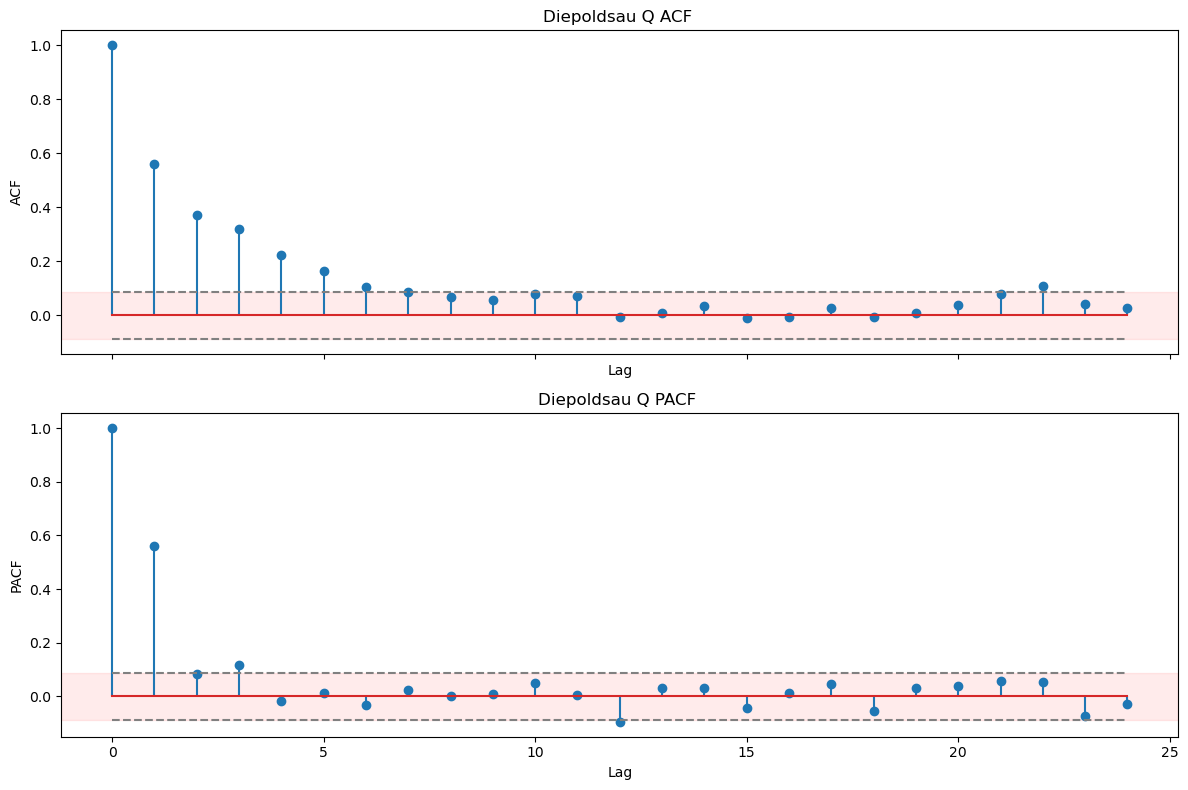


=== Diepoldsau C ===
  n after detrend+deseason: 169
  Gap detected at 2019-01-01 – splitting series.
  Segment "before gap": n=84
  Segment "after gap": n=85


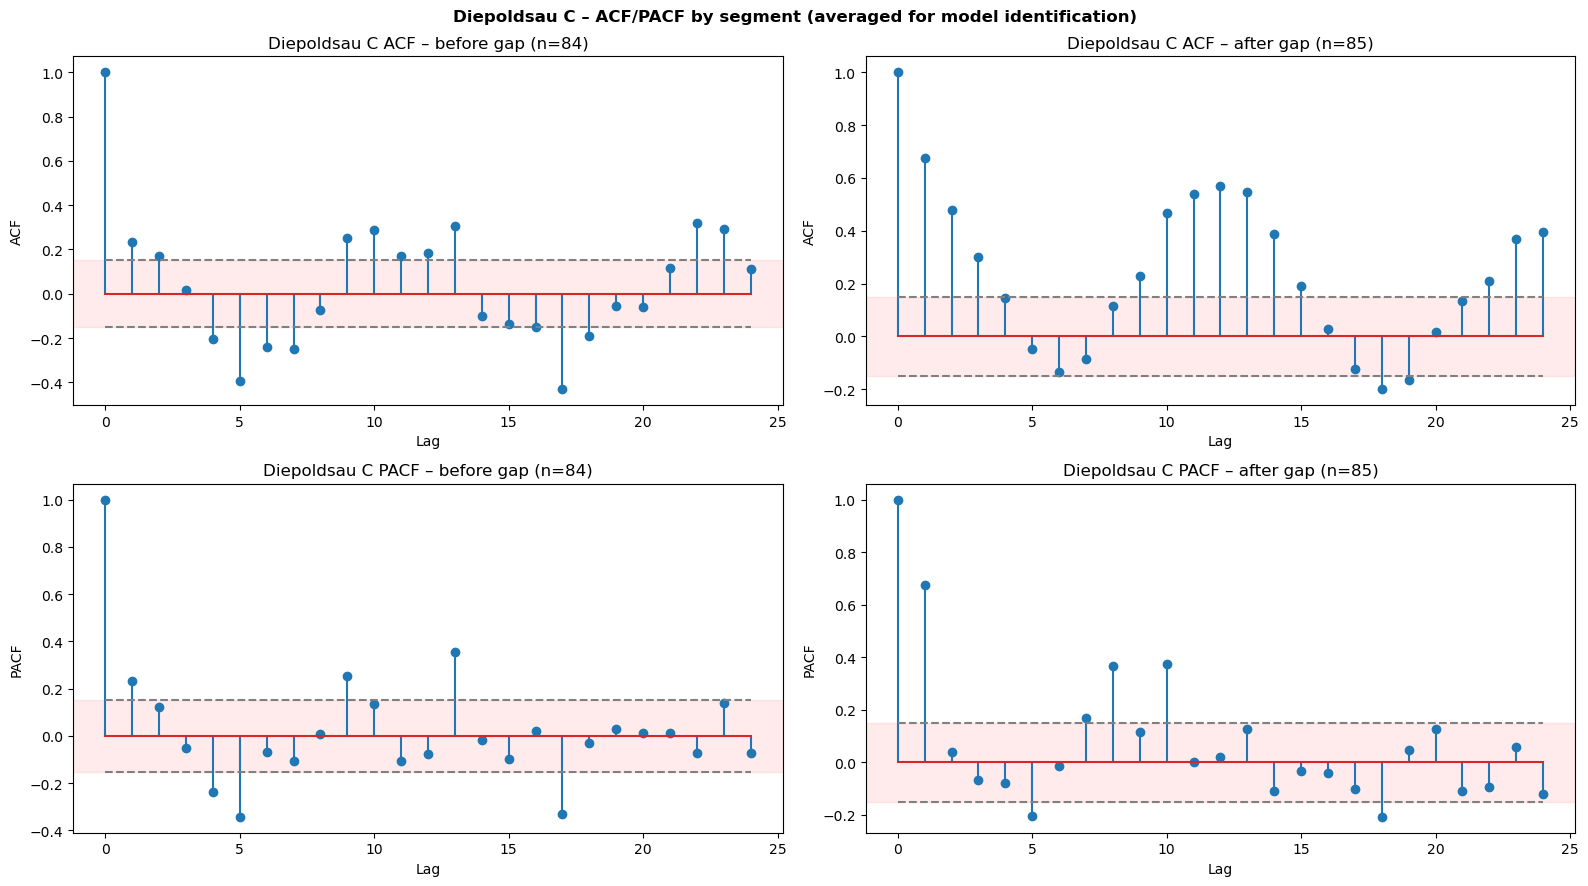

  Pearson r between segment ACFs: 0.770  (different memory structure)


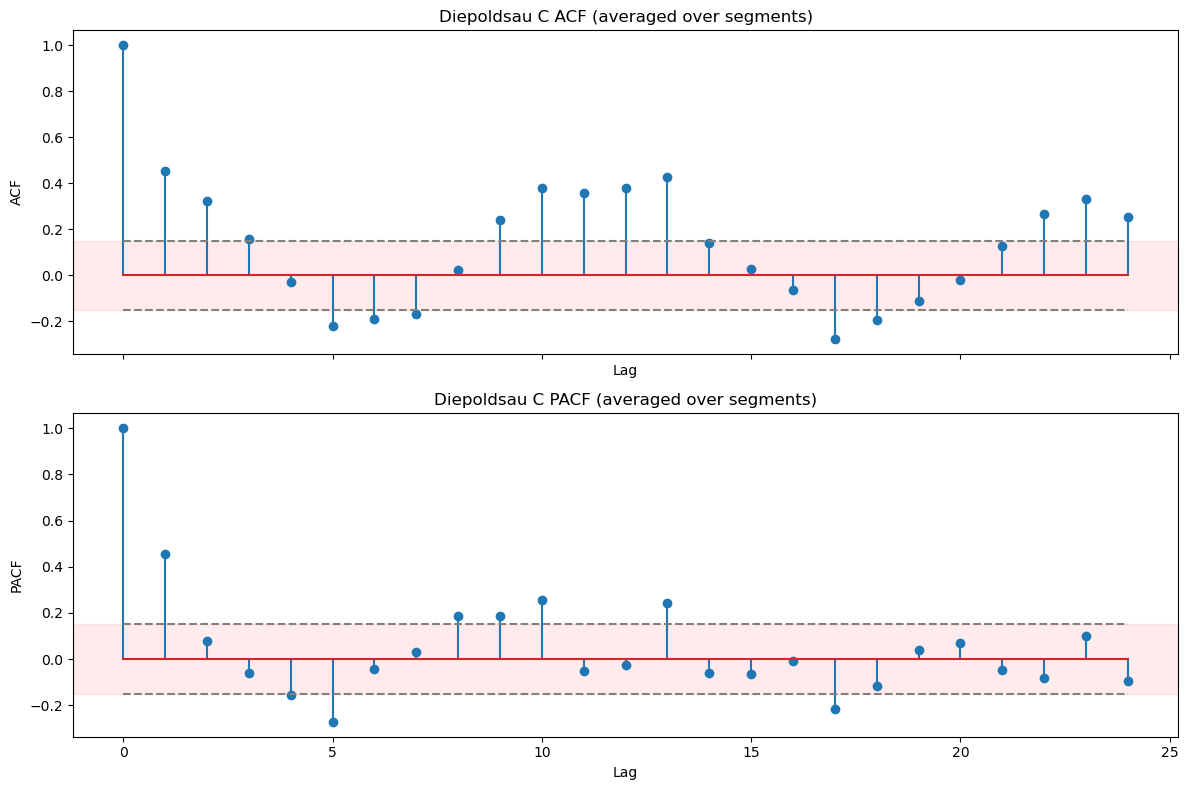


=== Gisingen Q ===
  n after detrend+deseason: 564


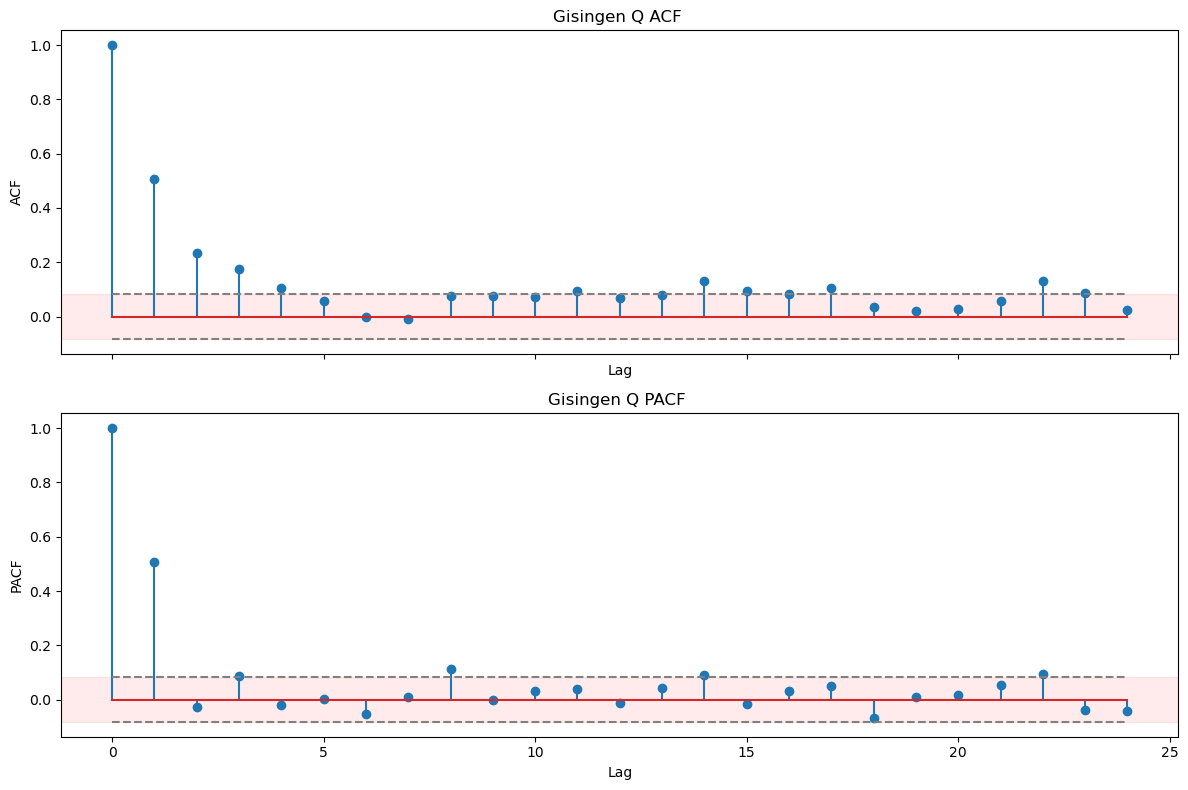


=== Gisingen C ===
  n after detrend+deseason: 192
  Gap detected at 2009-01-01 – splitting series.
  Segment "before gap": n=60
  Segment "after gap": n=132


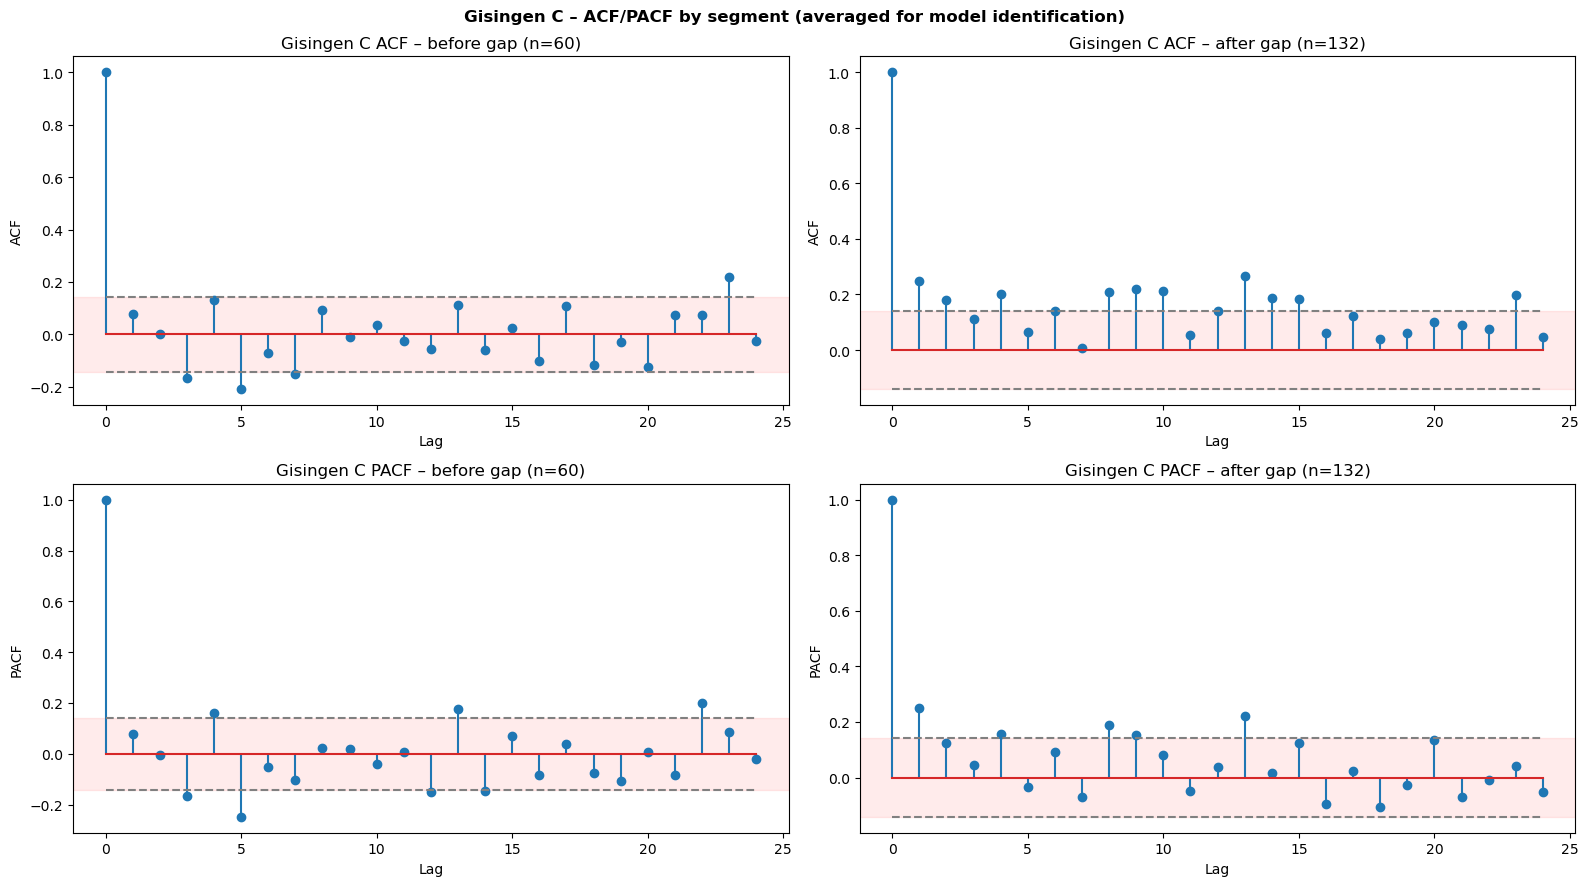

  Pearson r between segment ACFs: 0.605  (different memory structure)


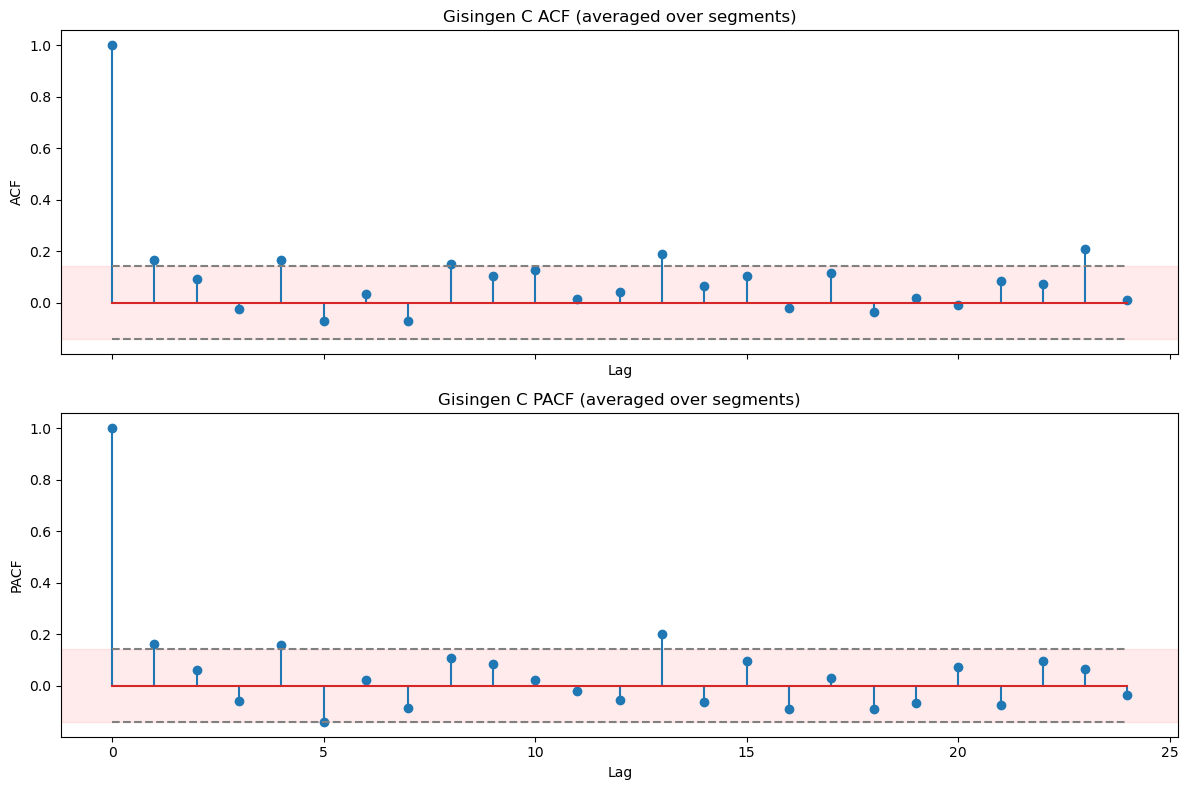

In [7]:
max_lag = 10   # appropriate for annual data

GAP_CONFIG = {
    'C_Diepoldsau': pd.Timestamp('2019-01-01'),
    'C_Gisingen':   pd.Timestamp('2009-01-01'),
}

def gap_aware_acf_pacf(series, max_lag, gap_date=None):
    n_full = len(series.dropna())
    conf   = 1.96 / np.sqrt(n_full)
    if gap_date is None:
        s      = series.dropna()
        acf_v  = acf(s,  nlags=max_lag, fft=False, missing='drop')
        pacf_v = pacf(s, nlags=max_lag, method='ywm')
        return acf_v, pacf_v, conf, None
    before = series[series.index <  gap_date].dropna()
    after  = series[series.index >= gap_date].dropna()
    segments, acfs, pacfs = {}, [], []
    for label, seg in [('before gap', before), ('after gap', after)]:
        if len(seg) < max_lag + 2:
            print(f'  Segment "{label}" too short ({len(seg)} obs) – skipping.')
            continue
        a  = acf(seg,  nlags=max_lag, fft=False, missing='drop')
        p_ = pacf(seg, nlags=max_lag, method='ywm')
        acfs.append(a); pacfs.append(p_)
        segments[label] = {'acf': a, 'pacf': p_, 'n': len(seg)}
        print(f'  Segment "{label}": n={len(seg)} years')
    if not acfs:
        raise ValueError('No valid segments found.')
    return np.mean(acfs, axis=0), np.mean(pacfs, axis=0), conf, segments

# No seasonal standardisation — use detrended series directly
z_series = {}

for key, raw_series in detrended_series.items():
    variable, station = key.split('_', 1)
    s = raw_series.dropna()
    z_series[key] = s
    print(f'\n=== {station} {variable} ===  (n={len(s)} years)')

    gap_date = GAP_CONFIG.get(key)
    if gap_date:
        print(f'  Gap flagged at {gap_date.date()} – splitting.')
    acf_avg, pacf_avg, conf, segments = gap_aware_acf_pacf(s, max_lag, gap_date)
    lags = np.arange(len(acf_avg))

    if segments:
        fig, axes = plt.subplots(2, 2, figsize=(16, 8))
        for col, (label, sd) in enumerate(segments.items()):
            for row, (vals, ylabel) in enumerate(
                    [(sd['acf'], 'ACF'), (sd['pacf'], 'PACF')]):
                axes[row, col].stem(lags, vals)
                axes[row, col].hlines([conf, -conf], 0, max_lag,
                                      colors='gray', linestyles='dashed')
                axes[row, col].axhspan(-conf, conf, alpha=0.08, color='red')
                axes[row, col].set_title(
                    f'{station} {variable} {ylabel} – {label} (n={sd["n"]} yr)')
                axes[row, col].set_xlabel('Lag (years)')
                axes[row, col].set_ylabel(ylabel)
        fig.suptitle(f'{station} {variable} – ACF/PACF by segment (annual)',
                     fontweight='bold')
        plt.tight_layout(); plt.show()
        r, _ = pearsonr(list(segments.values())[0]['acf'][1:],
                        list(segments.values())[1]['acf'][1:])
        print(f'  Pearson r between segment ACFs: {r:.3f} '
              f'({"similar" if r > 0.8 else "different – worth discussing"})')

    suffix = '(averaged over segments)' if segments else ''
    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    for ax, vals, ylabel in zip(axes, [acf_avg, pacf_avg], ['ACF', 'PACF']):
        ax.stem(lags, vals)
        ax.hlines([conf, -conf], 0, max_lag, colors='gray', linestyles='dashed')
        ax.axhspan(-conf, conf, alpha=0.08, color='red')
        ax.set_title(f'{station} {variable} {ylabel} {suffix} – annual data')
        ax.set_xlabel('Lag (years)'); ax.set_ylabel(ylabel)
    plt.tight_layout(); plt.show()


# 2.2 AR and ARMA model fitting (annual series)
With annual data and no seasonal structure, low-order models are expected to suffice.
Candidate search: AR(1..4), ARMA(1..4, 1..3) — well within professor's cap of 12.
With n ≈ 10–50 years, parsimony is especially important to avoid overfitting.


In [8]:
from statsmodels.tsa.arima_process import ArmaProcess

def select_order_from_acf_pacf(series, max_lag=10, max_order=4):
    n    = len(series.dropna())
    conf = 1.96 / np.sqrt(n)
    acf_v  = acf(series.dropna(), nlags=max_lag, fft=False, missing='drop')
    pacf_v = pacf(series.dropna(), nlags=max_lag, method='ywm')
    p = 0
    for lag in range(1, max_lag + 1):
        if abs(pacf_v[lag]) > conf: p = lag
        else: break
    q = 0
    for lag in range(1, max_lag + 1):
        if abs(acf_v[lag]) > conf: q = lag
        else: break
    return min(p, max_order), min(q, max_order)

def candidate_models(y, max_ar=4, max_ma=3):
    y = np.asarray(y.dropna(), dtype=float)
    results = []
    for p in range(1, max_ar + 1):
        try:
            m = ARIMA(y, order=(p, 0, 0)).fit()
            results.append(('AR', p, 0, m.aic, m.bic))
        except Exception as e:
            print(f'  AR({p}) failed: {e}')
    for p in range(1, max_ar + 1):
        for q in range(1, max_ma + 1):
            try:
                m = ARIMA(y, order=(p, 0, q)).fit()
                results.append(('ARMA', p, q, m.aic, m.bic))
            except Exception as e:
                print(f'  ARMA({p},{q}) failed: {e}')
    if not results:
        return pd.DataFrame(columns=['model','p','q','aic','bic'])
    return pd.DataFrame(results, columns=['model','p','q','aic','bic']).sort_values(['bic','aic'])

fitted_models = {}

for key, z in z_series.items():
    variable, station = key.split('_', 1)
    print(f'\n===== {station} {variable} =====')
    if len(z.dropna()) < 8:
        print('  Too few years – skipping.'); continue

    p_sug, q_sug = select_order_from_acf_pacf(z)
    print(f'  ACF/PACF suggested: p={p_sug}, q={q_sug}')

    selection = candidate_models(z)
    if selection.empty:
        print('  No model could be fitted.'); continue
    display(selection.head(10))

    best_ar = selection[selection['q'] == 0].head(1)
    if not best_ar.empty:
        ar_p = int(best_ar['p'].iloc[0])
        try:
            fm = ARIMA(z.dropna(), order=(ar_p, 0, 0)).fit()
            fitted_models[f'{key}_AR'] = fm
            print(f'  → Best AR:   AR({ar_p})          AIC={best_ar.aic.iloc[0]:.1f}  BIC={best_ar.bic.iloc[0]:.1f}')
        except Exception as e:
            print(f'  AR({ar_p}) refit failed: {e}')

    best_arma = selection[selection['q'] > 0].head(1)
    if not best_arma.empty:
        arma_p = int(best_arma['p'].iloc[0])
        arma_q = int(best_arma['q'].iloc[0])
        try:
            fm = ARIMA(z.dropna(), order=(arma_p, 0, arma_q)).fit()
            fitted_models[f'{key}_ARMA'] = fm
            print(f'  → Best ARMA: ARMA({arma_p},{arma_q})  AIC={best_arma.aic.iloc[0]:.1f}  BIC={best_arma.bic.iloc[0]:.1f}')
        except Exception as e:
            print(f'  ARMA({arma_p},{arma_q}) refit failed: {e}')



===== Diepoldsau Q =====
  ACF/PACF suggested: p=1, q=7


c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,model,p,q,aic,bic
0,AR,1,0,1240.585968,1253.271501
4,ARMA,1,1,1237.071634,1253.985678
2,AR,3,0,1233.758065,1254.900620
1,AR,2,0,1239.080540,1255.994584
5,ARMA,1,2,1235.686897,1256.829452
7,ARMA,2,1,1237.197017,1258.339572
8,ARMA,2,2,1235.245543,1260.616609
6,ARMA,1,3,1235.296936,1260.668002
10,ARMA,3,1,1235.539969,1260.911035
3,AR,4,0,1235.601010,1260.972076


  → Best AR: AR(1)  AIC=1240.6  BIC=1253.3
  → Best ARMA: ARMA(1,1)  AIC=1237.1  BIC=1254.0

===== Diepoldsau C =====
  ACF/PACF suggested: p=2, q=2


c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Sylvie\anaconda3

...

  → Best AR: AR(1)  AIC=1428.2  BIC=1441.2
  → Best ARMA: ARMA(1,1)  AIC=1429.6  BIC=1446.9

===== Gisingen C =====
  ACF/PACF suggested: p=1, q=1


c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Sylvie\anaconda3

,model,p,q,aic,bic
14,ARMA,4,2,462.486841,488.546804
8,ARMA,2,2,515.338204,534.883176
12,ARMA,3,3,513.103212,539.163175
0,AR,1,0,532.840852,542.613338
5,ARMA,1,2,527.385187,543.672664
15,ARMA,4,3,514.900237,544.217696
7,ARMA,2,1,529.958535,546.246012
1,AR,2,0,533.774440,546.804421
4,ARMA,1,1,533.884733,546.914714
6,ARMA,1,3,528.303210,547.848182


c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored whe

  → Best AR: AR(1)  AIC=532.8  BIC=542.6
  → Best ARMA: ARMA(4,2)  AIC=462.5  BIC=488.5


# 3. Timeseries application & evaluation
This section evaluates the fitted AR/ARMA models by comparing empirical and theoretical ACFs, analyzing residual autocorrelations, and testing for independence and normality of residuals.


===== Diepoldsau Q Evaluation =====


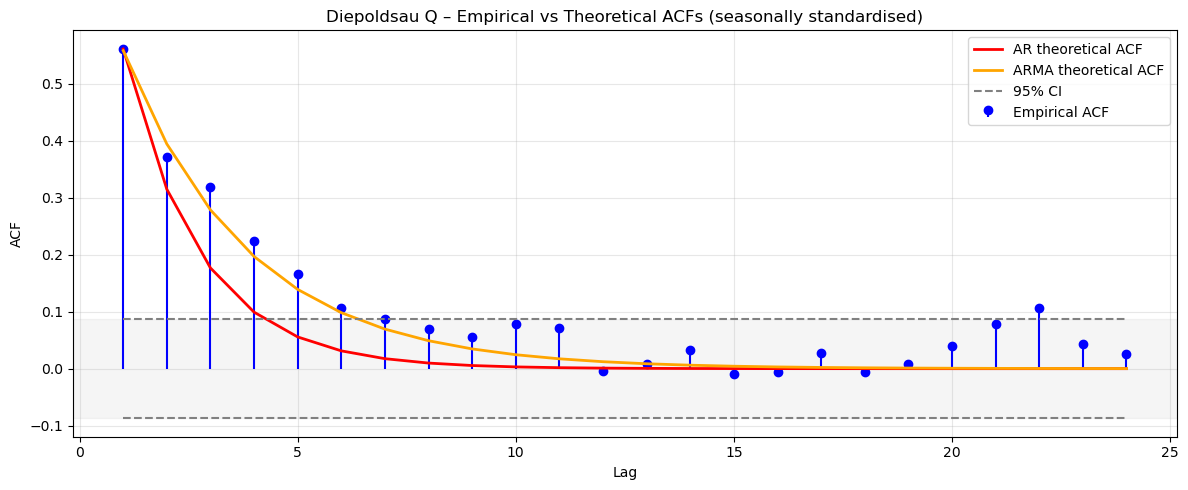

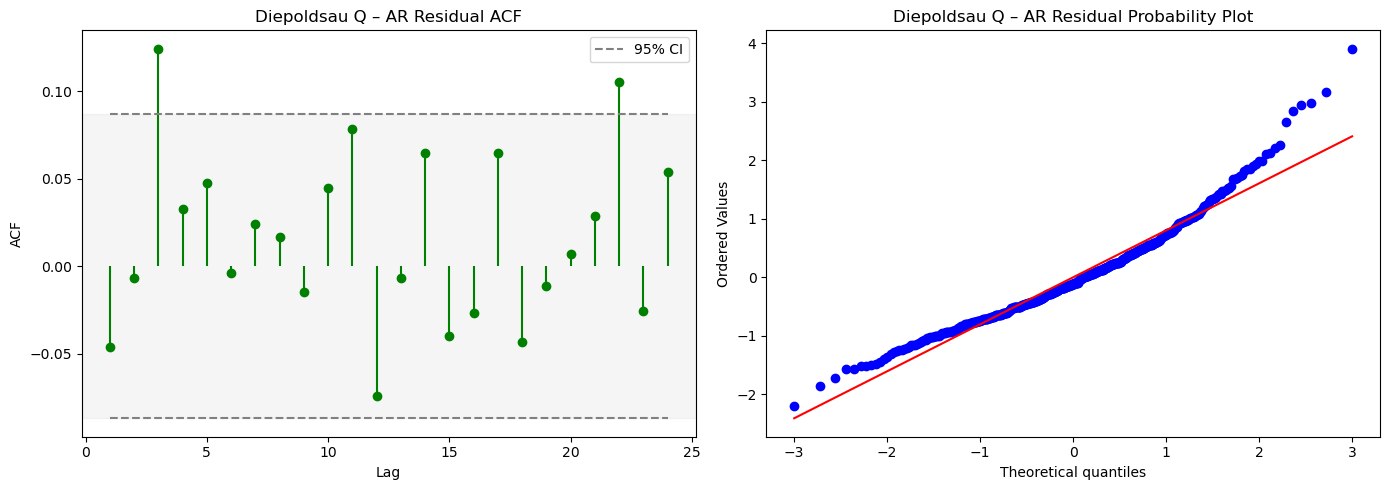

  AR Ljung-Box (lag=24): stat=33.43, p=0.0954  → residuals independent ✓
  AR Shapiro-Wilk normality:  stat=0.9574, p=0.0000  → residuals NOT normal ✗
  AR residual ACF significant at lags: [3, 22]



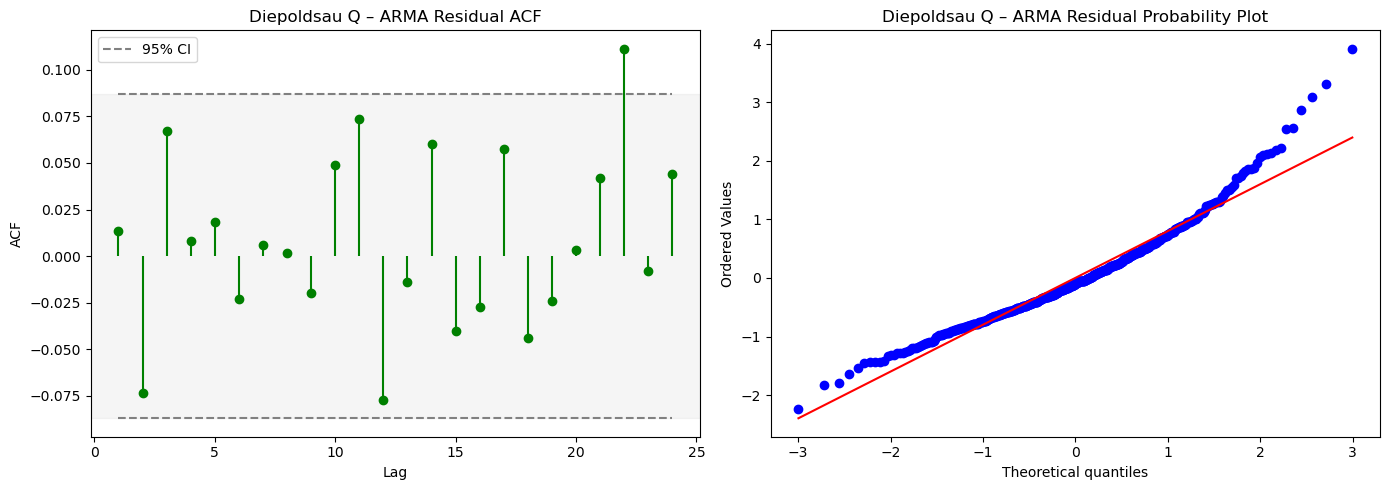

  ARMA Ljung-Box (lag=24): stat=27.95, p=0.2623  → residuals independent ✓
  ARMA Shapiro-Wilk normality:  stat=0.9582, p=0.0000  → residuals NOT normal ✗
  ARMA residual ACF significant at lags: [22]


===== Diepoldsau C Evaluation =====


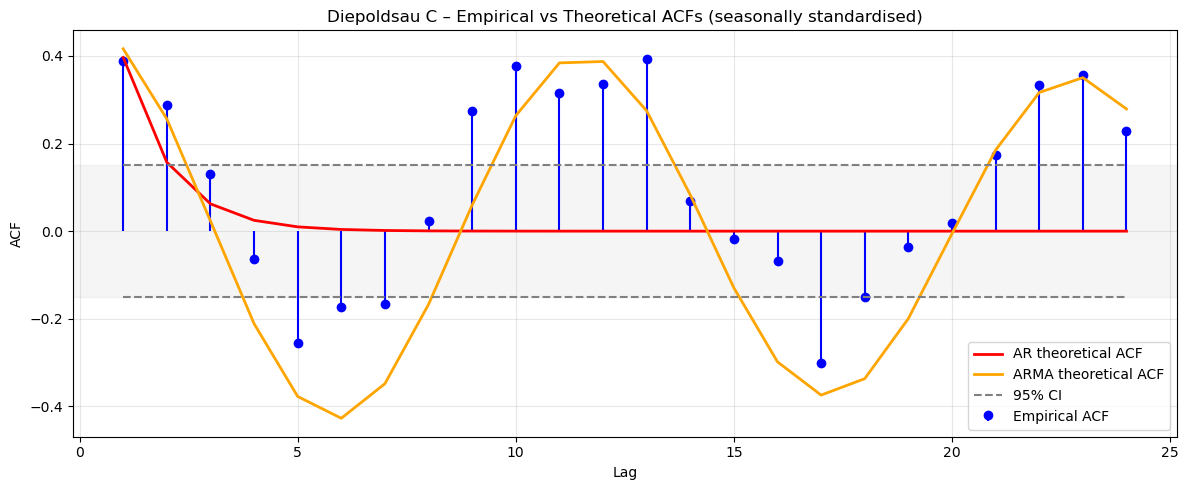

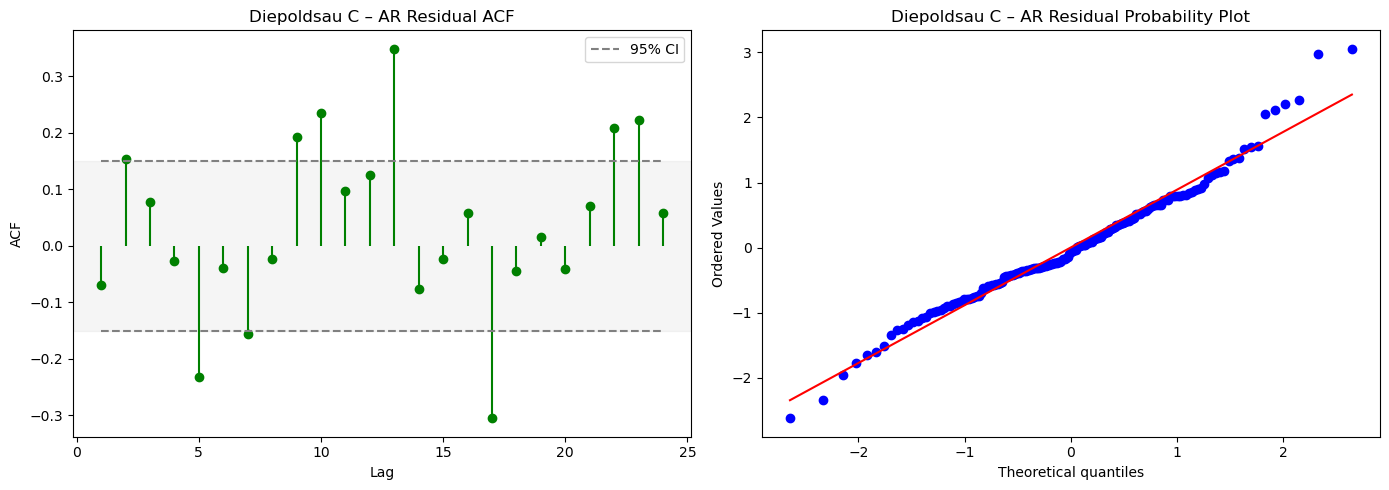

  AR Ljung-Box (lag=24): stat=104.60, p=0.0000  → residuals NOT independent ✗
  AR Shapiro-Wilk normality:  stat=0.9781, p=0.0090  → residuals NOT normal ✗
  AR residual ACF significant at lags: [2, 5, 7, 9, 10, 13, 17, 22, 23]



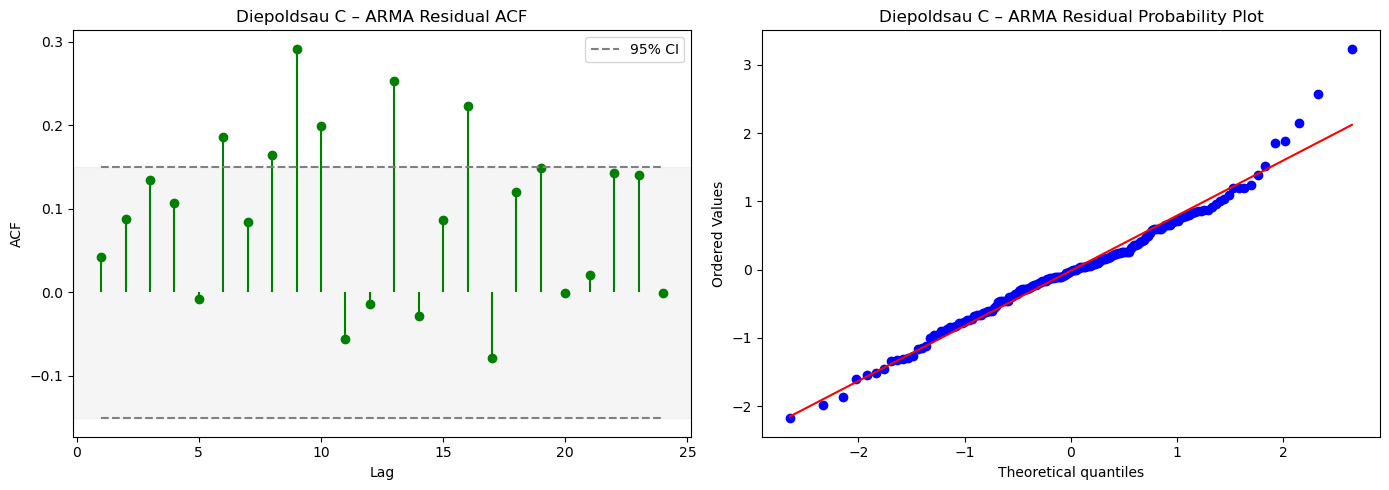

  ARMA Ljung-Box (lag=24): stat=81.42, p=0.0000  → residuals NOT independent ✗
  ARMA Shapiro-Wilk normality:  stat=0.9768, p=0.0063  → residuals NOT normal ✗
  ARMA residual ACF significant at lags: [6, 8, 9, 10, 13, 16]


===== Gisingen Q Evaluation =====


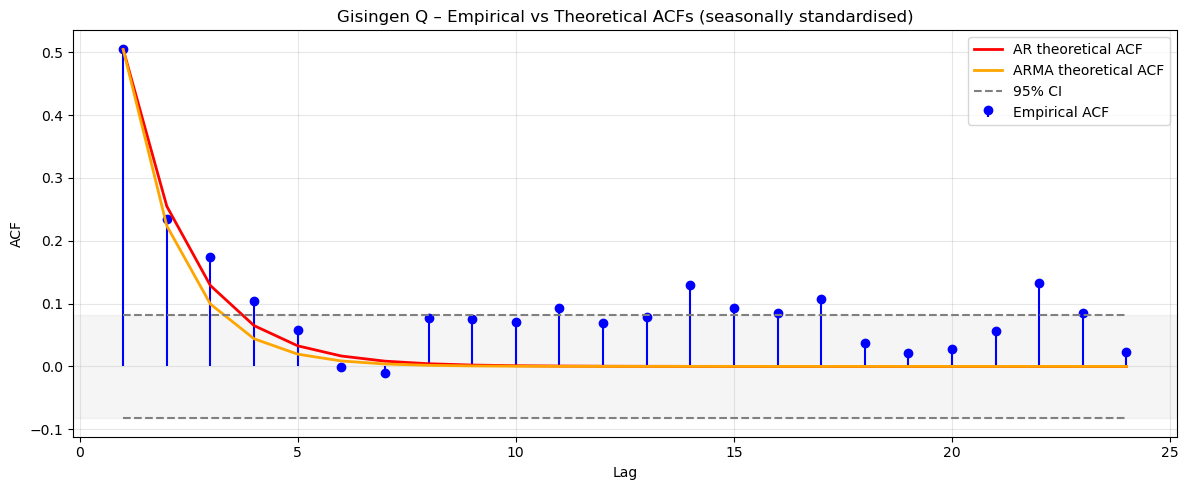

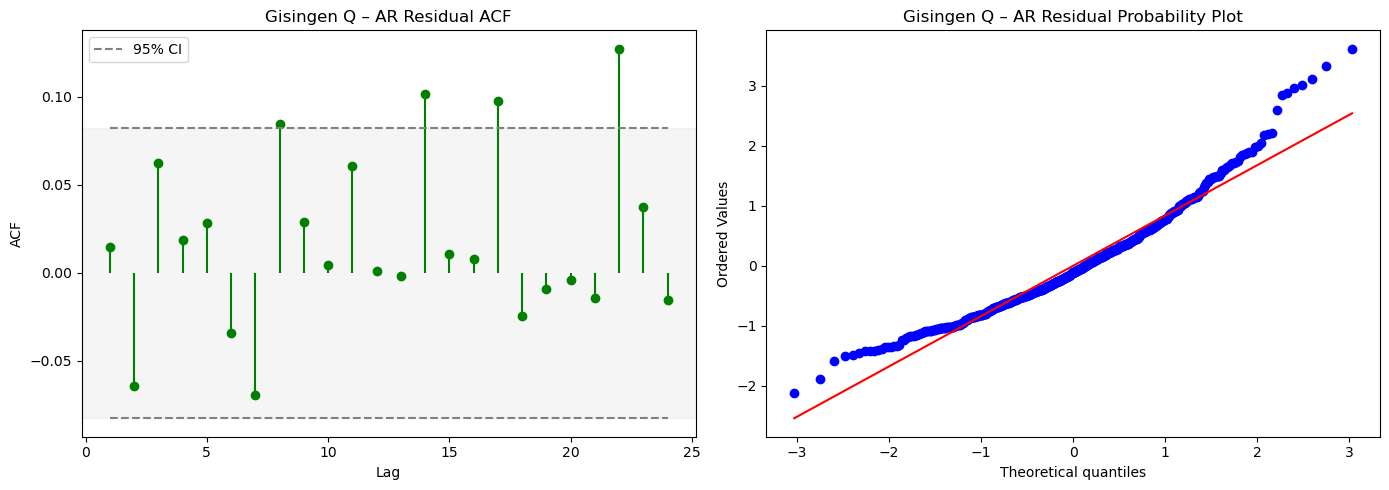

  AR Ljung-Box (lag=24): stat=38.14, p=0.0335  → residuals NOT independent ✗
  AR Shapiro-Wilk normality:  stat=0.9565, p=0.0000  → residuals NOT normal ✗
  AR residual ACF significant at lags: [8, 14, 17, 22]



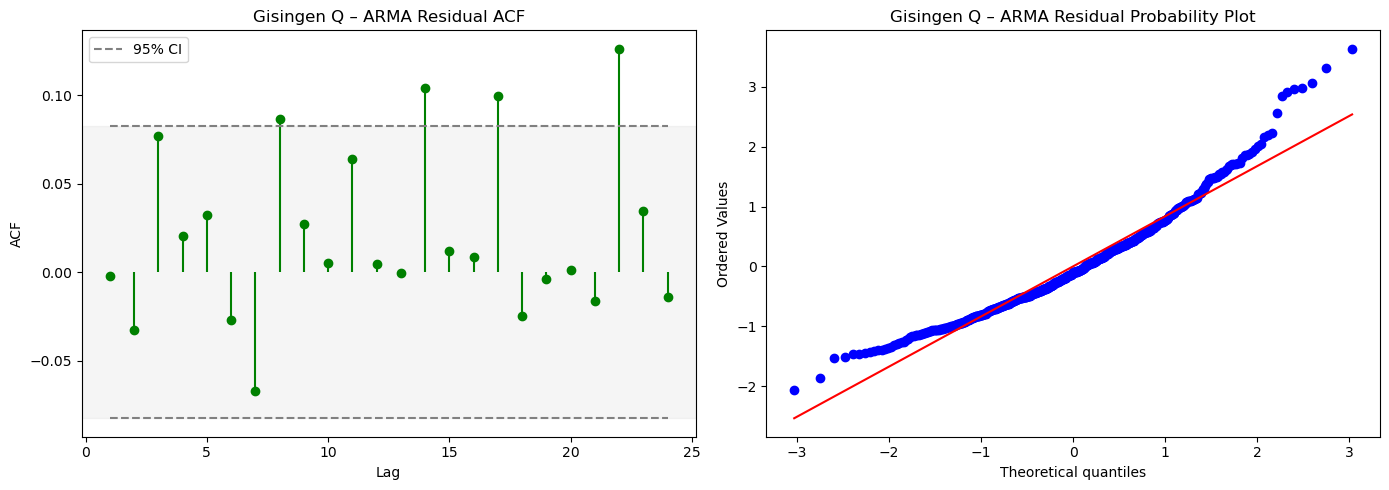

  ARMA Ljung-Box (lag=24): stat=37.92, p=0.0354  → residuals NOT independent ✗
  ARMA Shapiro-Wilk normality:  stat=0.9570, p=0.0000  → residuals NOT normal ✗
  ARMA residual ACF significant at lags: [8, 14, 17, 22]


===== Gisingen C Evaluation =====


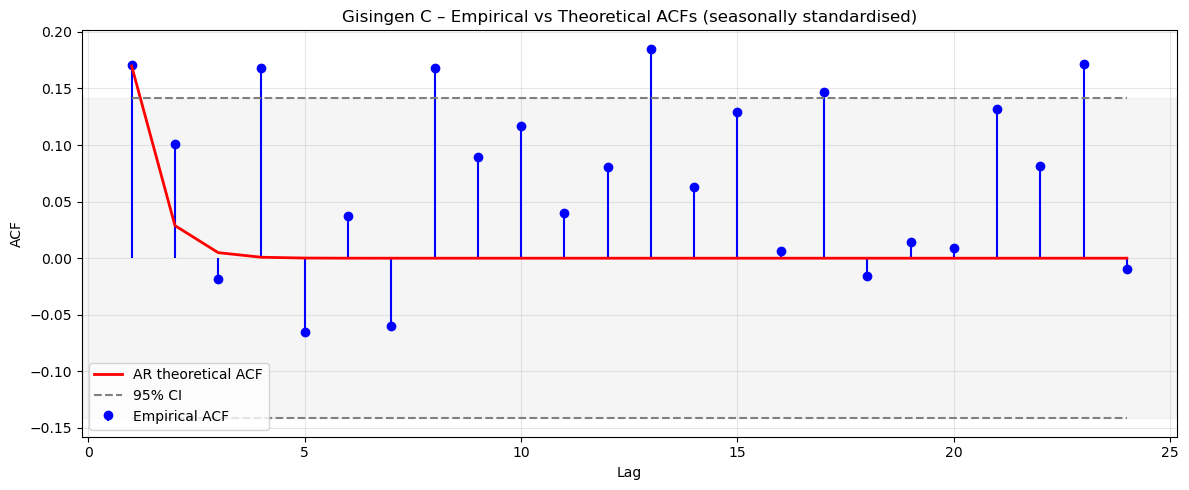

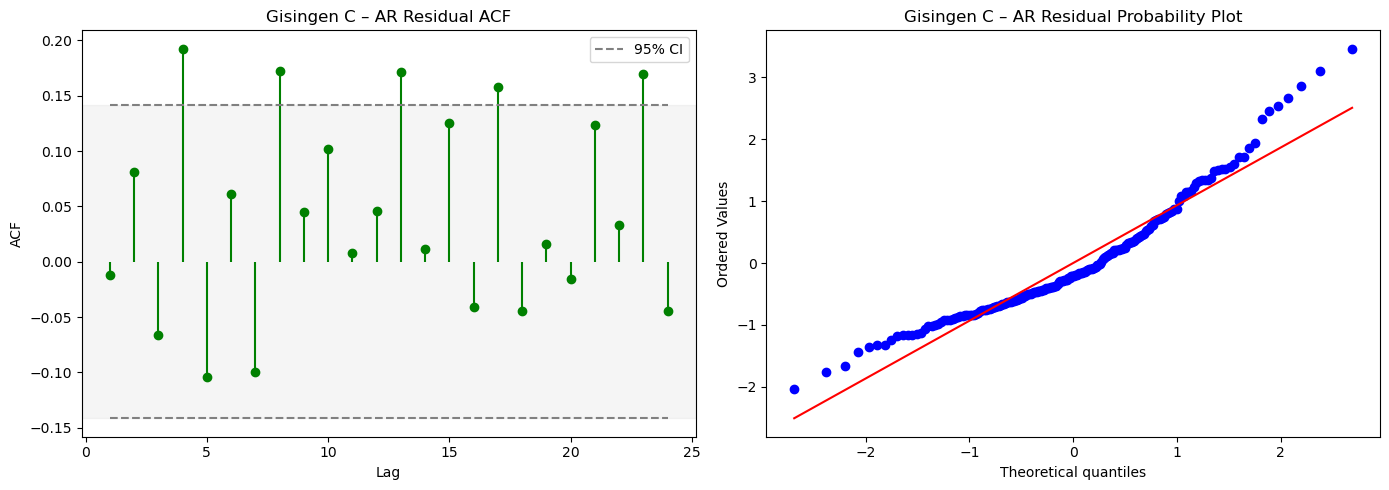

  AR Ljung-Box (lag=24): stat=49.37, p=0.0017  → residuals NOT independent ✗
  AR Shapiro-Wilk normality:  stat=0.9370, p=0.0000  → residuals NOT normal ✗
  AR residual ACF significant at lags: [4, 8, 13, 17, 23]



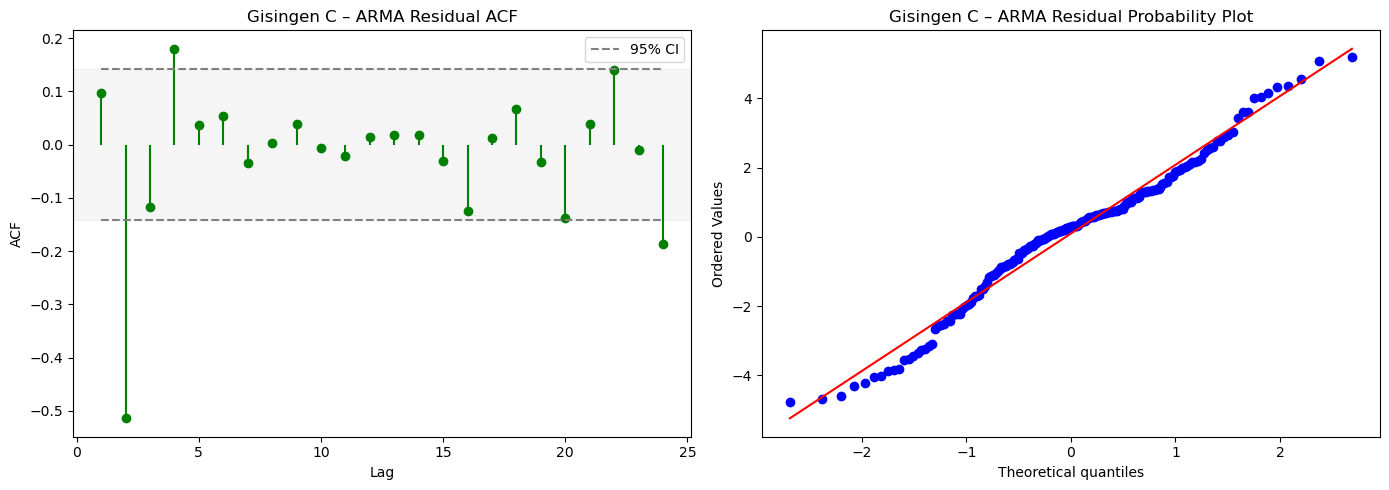

  ARMA Ljung-Box (lag=24): stat=85.78, p=0.0000  → residuals NOT independent ✗
  ARMA Shapiro-Wilk normality:  stat=0.9787, p=0.0051  → residuals NOT normal ✗
  ARMA residual ACF significant at lags: [2, 4, 24]



In [9]:
# ── Model evaluation ─────────────────────────────────────────────────────────
from statsmodels.tsa.arima_process import ArmaProcess
from scipy.stats import shapiro

max_lag = 10

def theoretical_acf(model_obj, max_lag):
    """Compute theoretical ACF from fitted ARIMA model using ArmaProcess.
    Returns None if the process is non-stationary (roots >= 1)."""
    ar = np.r_[1, -model_obj.arparams]   # statsmodels sign convention
    ma = np.r_[1,  model_obj.maparams]
    # Check stationarity: all roots of AR polynomial must be inside unit circle
    if len(ar) > 1:
        roots = np.roots(ar)
        if np.any(np.abs(roots) >= 1.0):
            print(f'  Warning: fitted AR params are non-stationary (max root={np.max(np.abs(roots)):.3f}) '
                  f'– theoretical ACF cannot be computed.')
            return None
    return ArmaProcess(ar, ma).acf(max_lag + 1)[1:]

for key, z in z_series.items():
    variable, station = key.split('_', 1)
    z_clean = z.dropna()
    n = len(z_clean)
    conf = 1.96 / np.sqrt(n)
    emp_acf = acf(z_clean, nlags=max_lag, fft=False, missing='drop')
    lags = np.arange(1, max_lag + 1)

    ar_model   = fitted_models.get(f'{key}_AR')
    arma_model = fitted_models.get(f'{key}_ARMA')

    print(f'\n===== {station} {variable} Evaluation =====')

    # ── (a) Empirical vs theoretical ACF ──────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.stem(lags, emp_acf[1:], label='Empirical ACF', linefmt='b-', markerfmt='bo', basefmt=' ')

    for model_obj, label, color in [
        (ar_model,   'AR theoretical ACF',   'red'),
        (arma_model, 'ARMA theoretical ACF', 'orange'),
    ]:
        if model_obj is not None:
            theo = theoretical_acf(model_obj, max_lag)
            if theo is not None:
                ax.plot(lags, theo, label=label, color=color, linewidth=2)

    ax.hlines([conf, -conf], 1, max_lag, colors='gray', linestyles='dashed', label='95% CI')
    ax.axhspan(-conf, conf, alpha=0.08, color='gray')
    ax.set_title(f'{station} {variable} – Empirical vs Theoretical ACFs (annual data – no seasonal standardisation needed)')
    ax.set_xlabel('Lag'); ax.set_ylabel('ACF'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    # ── (b) Residual ACF + Ljung-Box + normality per model ───────────────────
    for model_type, model_obj in [('AR', ar_model), ('ARMA', arma_model)]:
        if model_obj is None:
            continue
        residuals = model_obj.resid
        res_acf   = acf(residuals, nlags=max_lag, fft=False, missing='drop')

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].stem(lags, res_acf[1:], linefmt='g-', markerfmt='go', basefmt=' ')
        axes[0].hlines([conf, -conf], 1, max_lag, colors='gray', linestyles='dashed', label='95% CI')
        axes[0].axhspan(-conf, conf, alpha=0.08, color='gray')
        axes[0].set_title(f'{station} {variable} – {model_type} Residual ACF')
        axes[0].set_xlabel('Lag'); axes[0].set_ylabel('ACF'); axes[0].legend()

        probplot(residuals, dist='norm', plot=axes[1])
        axes[1].set_title(f'{station} {variable} – {model_type} Residual Probability Plot')

        plt.tight_layout(); plt.show()

        lb = acorr_ljungbox(residuals, lags=[max_lag], return_df=True)
        lb_p = lb['lb_pvalue'].iloc[0]
        print(f'  {model_type} Ljung-Box (lag={max_lag}): stat={lb["lb_stat"].iloc[0]:.2f}, '
              f'p={lb_p:.4f}  → residuals {"independent ✓" if lb_p > 0.05 else "NOT independent ✗"}')

        sw_stat, sw_p = shapiro(residuals)
        print(f'  {model_type} Shapiro-Wilk normality:  stat={sw_stat:.4f}, '
              f'p={sw_p:.4f}  → residuals {"normal ✓" if sw_p > 0.05 else "NOT normal ✗"}')

        sig_lags = [lag for lag in range(1, max_lag + 1) if abs(res_acf[lag]) > conf]
        if sig_lags:
            print(f'  {model_type} residual ACF significant at lags: {sig_lags}')
        else:
            print(f'  {model_type} residual ACF: all lags within 95% CI ✓')
        print()


In [11]:
# PPCC (Probability Plot Correlation Coefficient) for model residuals
from scipy.stats import probplot, shapiro
alpha = 0.05
print("="*60)
print("PPCC FOR MODEL RESIDUALS (notebook v4 (2))")
print(f"Decision alpha = {alpha:.2f}")
print("="*60)
rows = []
for key, model in fitted_models.items():
    try:
        resid = pd.Series(model.resid).dropna()
    except Exception:
        try:
            resid = pd.Series(model.resid())
        except Exception:
            print(f"{key}: could not extract residuals")
            continue
    if len(resid) < 3:
        print(f"{key}: too few residuals ({len(resid)})")
        continue
    (osm, osr), (slope, intercept, r) = probplot(resid, dist='norm', fit=True)
    sw_stat, sw_p = shapiro(resid)
    normal = sw_p > alpha
    print(f"{key}: PPCC={r:.4f}  Shapiro-p={sw_p:.4f}  normal={'YES' if normal else 'NO'}  n={len(resid)}")
    rows.append({
        'model': key,
        'order': getattr(model.model, 'order', None),
        'ppcc': float(r),
        'sw_p': float(sw_p),
        'normal': bool(normal),
        'n': len(resid)
    })

fitted_models_ppcc = pd.DataFrame(rows)

# display the summary table
fitted_models_ppcc

PPCC FOR MODEL RESIDUALS (notebook v4 (2))
Decision alpha = 0.05
Q_Diepoldsau_AR: PPCC=0.9777  Shapiro-p=0.0000  normal=NO  n=507
Q_Diepoldsau_ARMA: PPCC=0.9780  Shapiro-p=0.0000  normal=NO  n=507
C_Diepoldsau_AR: PPCC=0.9873  Shapiro-p=0.0090  normal=NO  n=169
C_Diepoldsau_ARMA: PPCC=0.9863  Shapiro-p=0.0063  normal=NO  n=169
Q_Gisingen_AR: PPCC=0.9777  Shapiro-p=0.0000  normal=NO  n=564
Q_Gisingen_ARMA: PPCC=0.9780  Shapiro-p=0.0000  normal=NO  n=564
C_Gisingen_AR: PPCC=0.9675  Shapiro-p=0.0000  normal=NO  n=192
C_Gisingen_ARMA: PPCC=0.9900  Shapiro-p=0.0051  normal=NO  n=192


,model,order,ppcc,sw_p,normal,n
0,Q_Diepoldsau_AR,"(1, 0, 0)",0.977690,6.131680e-11,False,507
1,Q_Diepoldsau_ARMA,"(1, 0, 1)",0.978033,8.298160e-11,False,507
2,C_Diepoldsau_AR,"(1, 0, 0)",0.987306,8.989155e-03,False,169
3,C_Diepoldsau_ARMA,"(2, 0, 2)",0.986279,6.268047e-03,False,169
4,Q_Gisingen_AR,"(1, 0, 0)",0.977683,7.424747e-12,False,564
5,Q_Gisingen_ARMA,"(1, 0, 1)",0.977964,9.031887e-12,False,564
6,C_Gisingen_AR,"(1, 0, 0)",0.967497,2.063931e-07,False,192
7,C_Gisingen_ARMA,"(4, 0, 2)",0.989980,5.056665e-03,False,192


In [12]:
# PPCC critical-value test (Monte Carlo)
from scipy.stats import probplot
alpha = 0.05
n_sims = 2000
print("="*60)
print(f"PPCC CRITICAL-VALUE TEST (alpha={alpha:.2f}, sims={n_sims})")
print("="*60)

crit_cache = {}
rows = []
for key, model in fitted_models.items():
    try:
        resid = pd.Series(model.resid).dropna()
    except Exception:
        try:
            resid = pd.Series(model.resid())
        except Exception:
            print(f"{key}: could not extract residuals")
            continue
    n = len(resid)
    if n < 5:
        print(f"{key}: too few residuals (n={n}), skipping")
        continue
    (osm, osr), (slope, intercept, r_obs) = probplot(resid, dist='norm', fit=True)

    if n in crit_cache:
        r_crit = crit_cache[n]
    else:
        rs = np.empty(n_sims)
        for i in range(n_sims):
            sim = np.random.normal(size=n)
            (_, _), (_, _, r_sim) = probplot(sim, dist='norm', fit=True)
            rs[i] = r_sim
        r_crit = np.quantile(rs, 1 - alpha)
        crit_cache[n] = float(r_crit)

    accept = r_obs >= r_crit
    decision = 'NOT reject (normal)' if accept else 'reject (not normal)'
    print(f"{key}: r={r_obs:.4f}  r_crit={r_crit:.4f}  decision: {decision}  n={n}")

    rows.append({'model': key, 'order': getattr(model.model, 'order', None), 'r': float(r_obs), 'r_crit': float(r_crit), 'accept': bool(accept), 'n': n})

fitted_models_ppcc_crit = pd.DataFrame(rows)

# show summary
fitted_models_ppcc_crit

PPCC CRITICAL-VALUE TEST (alpha=0.05, sims=2000)
Q_Diepoldsau_AR: r=0.9777  r_crit=0.9993  decision: reject (not normal)  n=507
Q_Diepoldsau_ARMA: r=0.9780  r_crit=0.9993  decision: reject (not normal)  n=507
C_Diepoldsau_AR: r=0.9873  r_crit=0.9984  decision: reject (not normal)  n=169
C_Diepoldsau_ARMA: r=0.9863  r_crit=0.9984  decision: reject (not normal)  n=169
Q_Gisingen_AR: r=0.9777  r_crit=0.9994  decision: reject (not normal)  n=564
Q_Gisingen_ARMA: r=0.9780  r_crit=0.9994  decision: reject (not normal)  n=564
C_Gisingen_AR: r=0.9675  r_crit=0.9985  decision: reject (not normal)  n=192
C_Gisingen_ARMA: r=0.9900  r_crit=0.9985  decision: reject (not normal)  n=192


,model,order,r,r_crit,accept,n
0,Q_Diepoldsau_AR,"(1, 0, 0)",0.977690,0.999321,False,507
1,Q_Diepoldsau_ARMA,"(1, 0, 1)",0.978033,0.999321,False,507
2,C_Diepoldsau_AR,"(1, 0, 0)",0.987306,0.998358,False,169
3,C_Diepoldsau_ARMA,"(2, 0, 2)",0.986279,0.998358,False,169
4,Q_Gisingen_AR,"(1, 0, 0)",0.977683,0.999370,False,564
5,Q_Gisingen_ARMA,"(1, 0, 1)",0.977964,0.999370,False,564
6,C_Gisingen_AR,"(1, 0, 0)",0.967497,0.998506,False,192
7,C_Gisingen_ARMA,"(4, 0, 2)",0.989980,0.998506,False,192


In [13]:
# Portmanteau (Ljung-Box) test for residual independence
from statsmodels.stats.diagnostic import acorr_ljungbox
alpha = 0.05
lags = [3, 6, 10]

rows = []
print("="*60)
print(f"Portmanteau (Ljung-Box) test - alpha={alpha:.2f}")
print("="*60)

for key, model in fitted_models.items():
    try:
        resid = pd.Series(model.resid).dropna()
    except Exception:
        try:
            resid = pd.Series(model.resid())
        except Exception:
            print(f"{key}: could not extract residuals")
            continue
    n = len(resid)
    if n < max(lags) + 1:
        print(f"{key}: too few residuals (n={n}) for lags {lags}, skipping")
        continue

    lb = acorr_ljungbox(resid, lags=lags, return_df=True)
    decisions = {}
    for lag in lags:
        p = float(lb.loc[lag, 'lb_pvalue'])
        decisions[f'p_lag_{lag}'] = p
        decisions[f'indep_lag_{lag}'] = p > alpha

    overall_indep = all(decisions[f'indep_lag_{lag}'] for lag in lags)
    print(f"{key}: n={n}  -> " + "  ".join([f"lag{lag}: p={decisions[f'p_lag_{lag}']:.4f}" for lag in lags]) + f"  -> {'independent ✓' if overall_indep else 'NOT independent ✗'}")

    row = {'model': key, 'n': n, 'overall_independent': overall_indep}
    row.update(decisions)
    rows.append(row)

fitted_models_portmanteau = pd.DataFrame(rows)

# display summary
fitted_models_portmanteau

Portmanteau (Ljung-Box) test - alpha=0.05
Q_Diepoldsau_AR: n=507  -> lag6: p=0.0961  lag12: p=0.1022  lag24: p=0.0954  -> independent ✓
Q_Diepoldsau_ARMA: n=507  -> lag6: p=0.4628  lag12: p=0.3670  lag24: p=0.2623  -> independent ✓
C_Diepoldsau_AR: n=169  -> lag6: p=0.0147  lag12: p=0.0000  lag24: p=0.0000  -> NOT independent ✗
C_Diepoldsau_ARMA: n=169  -> lag6: p=0.0434  lag12: p=0.0000  lag24: p=0.0000  -> NOT independent ✗
Q_Gisingen_AR: n=564  -> lag6: p=0.4238  lag12: p=0.2173  lag24: p=0.0335  -> NOT independent ✗
Q_Gisingen_ARMA: n=564  -> lag6: p=0.5090  lag12: p=0.2444  lag24: p=0.0354  -> NOT independent ✗
C_Gisingen_AR: n=192  -> lag6: p=0.0528  lag12: p=0.0243  lag24: p=0.0017  -> NOT independent ✗
C_Gisingen_ARMA: n=192  -> lag6: p=0.0000  lag12: p=0.0000  lag24: p=0.0000  -> NOT independent ✗


,model,n,overall_independent,p_lag_6,indep_lag_6,p_lag_12,indep_lag_12,p_lag_24,indep_lag_24
0,Q_Diepoldsau_AR,507,True,9.612920e-02,True,1.022054e-01,True,9.541068e-02,True
1,Q_Diepoldsau_ARMA,507,True,4.627612e-01,True,3.670086e-01,True,2.622625e-01,True
2,C_Diepoldsau_AR,169,False,1.468490e-02,False,3.774191e-05,False,4.877957e-12,False
3,C_Diepoldsau_ARMA,169,False,4.344838e-02,False,2.953917e-05,False,3.605655e-08,False
4,Q_Gisingen_AR,564,False,4.237707e-01,True,2.173378e-01,True,3.352932e-02,False
5,Q_Gisingen_ARMA,564,False,5.090158e-01,True,2.443977e-01,True,3.535541e-02,False
6,C_Gisingen_AR,192,False,5.284742e-02,True,2.433584e-02,False,1.703199e-03,False
7,C_Gisingen_ARMA,192,False,8.214956e-12,False,3.629076e-09,False,7.116992e-09,False
